In [90]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import gradio as gr

In [91]:
df= pd.read_csv("/content/student_exam_pass.csv")

In [92]:
df.head()

,Hours_Studied,Attendance,Passed
0,3.7,43.1,0
1,9.5,71.9,1
2,7.3,72.4,1
3,6.0,78.2,0
4,1.6,83.6,0


In [93]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Hours_Studied  300 non-null    float64
 1   Attendance     300 non-null    float64
 2   Passed         300 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 7.2 KB


In [94]:
df.describe()

,Hours_Studied,Attendance,Passed
count,300.000000,300.000000,300.000000
mean,4.954667,70.651333,0.556667
std,2.942710,18.155835,0.497609
min,0.100000,40.700000,0.000000
25%,2.400000,54.975000,0.000000
50%,5.100000,71.300000,1.000000
75%,7.600000,86.375000,1.000000
max,9.900000,100.000000,1.000000


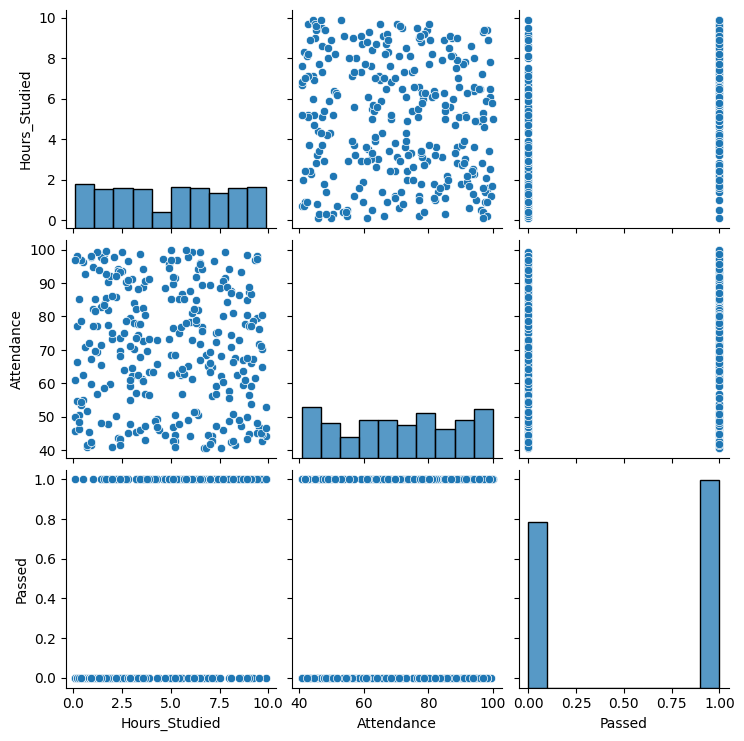

In [95]:
sns.pairplot(df)
plt.show()

In [96]:
X = df.drop('Passed', axis=1)
y = df['Passed']

In [97]:
feature_columns = X.columns.tolist()

In [98]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [99]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [100]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [101]:
y_pred = model.predict(X_test)

In [102]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy = ", accuracy)
print(classification_report(y_test, y_pred))

Accuracy =  0.8166666666666667
              precision    recall  f1-score   support

           0       0.77      0.80      0.78        25
           1       0.85      0.83      0.84        35

    accuracy                           0.82        60
   macro avg       0.81      0.81      0.81        60
weighted avg       0.82      0.82      0.82        60



In [109]:

def predict_student(hours_studied, attendance):

    # Create input with EXACT same column names
    input_data = pd.DataFrame({
        "Hours_Studied": [hours_studied],
        "Attendance": [attendance]
    })

    # Prediction
    prediction = model.predict(input_data)[0]

    # Probability
    probability = model.predict_proba(input_data)[0][1]

    if prediction == 1:
        result = "Pass ✅"
    else:
        result = "Fail ❌"

    return (
        f"Student Status : {result}\n"
        f"Pass Rate : {probability * 100:.2f}%"
    )


# =========================
# 7. Gradio Interface
# =========================

interface = gr.Interface(
    fn=predict_student,

    inputs=[
        gr.Slider(
            minimum=0,
            maximum=10,
            step=0.5,
            value=5,
            label="عدد ساعات المذاكرة - Hours Studied"
        ),

        gr.Slider(
            minimum=0,
            maximum=100,
            step=1,
            value=75,
            label="نسبة الحضور - Attendance"
        )
    ],

    outputs=gr.Textbox(
        label="النتيجة المتوقعة- Expected Result"
    ),

    title="🎓 Student Exam Pass Prediction",

    description=(
        "أدخل عدد ساعات المذاكرة ونسبة الحضور "
        "لتوقع نجاح الطالب في الامتحان."
    )
)

interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://f173892d7364f4b961.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
